In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz, solve, pinv,inv
from scipy.signal import lfilter, freqz 

# Fiche de Révision : Modélisation Paramétrique (Méthode de Padé)

Cette fiche traite de l'approximation d'un signal par un modèle rationnel (pôles et zéros), une technique fondamentale pour la compression d'information et la conception de filtres numériques.

---

## 1. Principe de la Modélisation ARMA

L'objectif est d'approcher un signal observé $x(n)$ par la réponse impulsionnelle d'un système linéaire invariant dans le temps (LTI) dont la fonction de transfert est rationnelle :
$$H(z) = \frac{B(z)}{A(z)} = \frac{\sum_{j=0}^{q} b_j z^{-j}}{1 + \sum_{i=1}^{p} a_i z^{-i}}$$

Le modèle est noté **ARMA(p, q)**, où :
* **p** représente l'ordre du dénominateur (nombre de pôles).
* **q** représente l'ordre du numérateur (nombre de zéros).

Le signal reconstruit $\hat{x}(n)$ obéit à l'équation de récurrence :
$$\hat{x}(n) = -\sum_{i=1}^{p} a_i \hat{x}(n-i) + \sum_{j=0}^{q} b_j \delta(n-j)$$

---

## 2. La Méthode de Padé

La méthode de Padé est une technique d'identification déterministe. Elle cherche à ce que les $L = p + q + 1$ premiers échantillons du signal reconstruit soient **exactement égaux** aux échantillons du signal original :
$$\hat{x}(n) = x(n) \quad \text{pour} \quad n = 0, 1, \dots, p+q$$

### A. Calcul des coefficients du dénominateur ($a_i$)
Pour isoler les coefficients $a_i$, on utilise les échantillons du signal à partir de l'indice $n > q$. On résout le système d'équations linéaires suivant :
$$\sum_{i=1}^{p} a_i x(n-i) = -x(n) \quad \text{pour} \quad n = q+1, \dots, q+p$$

Sous forme matricielle, cela revient à inverser une matrice de convolution $X_q$ :
$$\mathbf{X}_q \mathbf{a}_p = -\mathbf{x}_{q+1}$$

### B. Calcul des coefficients du numérateur ($b_j$)
Une fois les $a_i$ connus, les coefficients $b_j$ sont calculés directement par une simple convolution sur les premiers indices :
$$b_n = x(n) + \sum_{i=1}^{\min(n, p)} a_i x(n-i) \quad \text{pour} \quad n = 0, \dots, q$$

---

## 3. Analyse de la Stabilité et de l'Erreur

### A. Convergence vs Divergence
Un aspect critique révélé dans les exercices est la **stabilité** du modèle :
* Si les pôles du système (racines de $A(z)$) se trouvent à l'intérieur du cercle unité ($|z| < 1$), le signal reconstruit est stable et s'amortit.
* Si un pôle se trouve à l'extérieur ($|z| > 1$), le signal diverge vers l'infini.

**Exemple du Notebook** : Pour le signal $x(n) = 3(0.5)^n$ ($n>0$), un modèle **AR(2)** ($p=2, q=0$) s'est révélé instable car il tentait de compenser l'absence de "zéro" ($q$) par des pôles mal placés, provoquant une explosion du signal. À l'inverse, le modèle **ARMA(1,1)** était parfait car il correspondait à la structure physique réelle du signal.

### B. Erreur de Moindres Carrés ($E_{ls}$)
Pour évaluer la qualité du modèle sur la durée totale $N$ du signal, on calcule l'énergie de l'erreur :
$$E_{ls} = \sum_{n=0}^{N-1} |x(n) - \hat{x}(n)|^2$$
* Une erreur nulle signifie que le modèle a parfaitement capturé la dynamique du signal.

---

## 4. Application : Design de Filtre (Sinc)

La méthode de Padé peut servir à synthétiser un filtre à partir d'une réponse impulsionnelle idéale, comme la fonction **sinc** décalée pour un filtre passe-bas :
$$h(n) = 2 F_p \text{sinc}(2 F_p (n - n_d))$$

### Limites de l'approche locale
L'exercice montre que Padé, étant une méthode "exacte" sur un petit nombre de points ($p+q+1$), peut échouer à représenter correctement le comportement à long terme du filtre :
1.  **Troncature** : Travailler sur un nombre fini de points $N$ crée des ondulations dans le domaine fréquentiel (phénomène de Gibbs).
2.  **Sensibilité** : De faibles variations dans les premiers échantillons peuvent mener à des filtres instables.
3.  **Réponse Fréquentielle** : Le filtre identifié suit le gabarit idéal dans la bande passante, mais peut présenter des pics d'oscillation (ripples) importants juste avant la fréquence de coupure $F_p$.

---

## Concepts Clés pour l'Examen

* **Matrice de Toeplitz** : Structure de la matrice de convolution utilisée pour résoudre les équations de Padé.
* **Impulsion** : Pour reconstruire le signal $\hat{x}(n)$, on applique une impulsion $\delta(n)$ à l'entrée du filtre $(B, A)$ via la fonction `lfilter`.
* **Choix des ordres (p, q)** : Un ordre trop faible ne capture pas la complexité ; un ordre inadapté (ex: AR pur pour un signal ARMA) mène souvent à l'instabilité.

# Exercice 4.1 : Approximation de Padé
(M.Tognolini HEIG-VD 2026  MA-StatDig)

## 4.1.1.  Introduction et Définition du Signal
L'objectif est de tester l'approximation de Padé sur un signal test $x(n)$. Le signal est défini sur $N=12$ échantillons par :
$$x(n) = [1, 3 \cdot (0.5)^n] \text{ pour } n=1..N-1$$

In [2]:
# Paramètres du signal
N = 12
n = np.arange(N)
xn = np.zeros(N)
xn[0] = 1.0
xn[1:] = 3 * (0.5)**n[1:]

print("Signal xn (12 échantillons) :") # faire un table  a  2  colonnes : n et xn
print("n\t\txn")
for i in range(len(n)):
    print(f"{n[i]}\t\t{xn[i]}")

Signal xn (12 échantillons) :
n		xn
0		1.0
1		1.5
2		0.75
3		0.375
4		0.1875
5		0.09375
6		0.046875
7		0.0234375
8		0.01171875
9		0.005859375
10		0.0029296875
11		0.00146484375


## 4.1.2. Test a) : Modèle AR(2) ($p=2, q=0$)
Dans ce cas, nous cherchons un modèle purement auto-régressif. 
La démarche consiste à :
1. Construire la matrice de convolution $X$.
2. Extraire la matrice $X_q$ et le vecteur $x_{q+1}$ (échantillons de $q+1$ à $q+p$).
3. Résoudre le système $X_q \mathbf{a}_p = -\mathbf{x}_{q+1}$ pour trouver les coefficients du dénominateur.

Pour la mtrice de convolution utiliser la  fonction:
```Python
# Construction de la matrice de convolution (équivalent convmtx)
def get_conv_mtx(x, p_val):
    col = x
    row = np.zeros(p_val + 1)
    row[0] = x[0]
    return toeplitz(col, row)
```

Matrice de convolution X_full :
 [[1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.50000000e+00 1.00000000e+00 0.00000000e+00]
 [7.50000000e-01 1.50000000e+00 1.00000000e+00]
 [3.75000000e-01 7.50000000e-01 1.50000000e+00]
 [1.87500000e-01 3.75000000e-01 7.50000000e-01]
 [9.37500000e-02 1.87500000e-01 3.75000000e-01]
 [4.68750000e-02 9.37500000e-02 1.87500000e-01]
 [2.34375000e-02 4.68750000e-02 9.37500000e-02]
 [1.17187500e-02 2.34375000e-02 4.68750000e-02]
 [5.85937500e-03 1.17187500e-02 2.34375000e-02]
 [2.92968750e-03 5.85937500e-03 1.17187500e-02]
 [1.46484375e-03 2.92968750e-03 5.85937500e-03]]

Matrice Xq :
 [[1.  0. ]
 [1.5 1. ]]

Vecteur xq_1 :
 [1.5  0.75]

Coefficients ap : [ 1.  -1.5  1.5]
Coefficients bq : [1.]
Erreur Els : 247.1383


<>:54: SyntaxWarning: invalid escape sequence '\h'
<>:62: SyntaxWarning: invalid escape sequence '\h'
<>:54: SyntaxWarning: invalid escape sequence '\h'
<>:62: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_73134/3848063964.py:54: SyntaxWarning: invalid escape sequence '\h'
  plt.stem(n, x_hat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
/tmp/ipykernel_73134/3848063964.py:62: SyntaxWarning: invalid escape sequence '\h'
  plt.stem(n, error_vec, linefmt='m-', markerfmt='mo', label='Erreur $x(n) - \hat{x}(n)$')


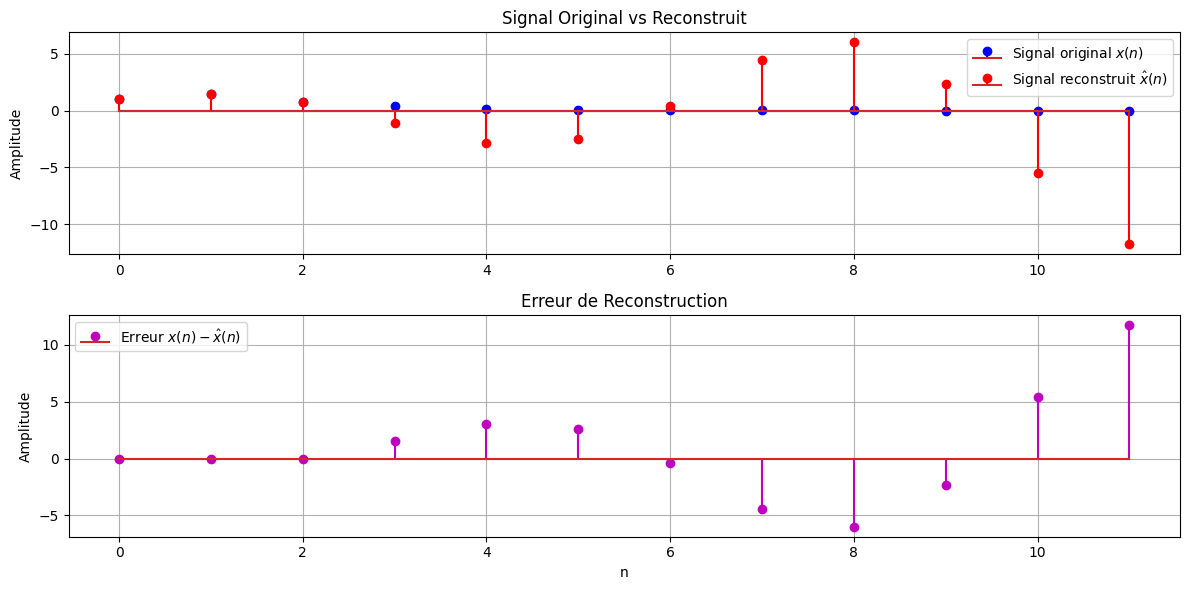

In [6]:
# Construction de la matrice de convolution (équivalent convmtx)
def get_conv_mtx(x, p_val):
    col = x
    row = np.zeros(p_val + 1)
    row[0] = x[0]
    return toeplitz(col, row)

# --- 1. Paramètres du modèle ---
p = 2
q = 0

# --- 2. Construction de la matrice de convolution complète ---
X_full = get_conv_mtx(xn, p)
print("Matrice de convolution X_full :\n", X_full)

# --- 3. Extraction pour la méthode de Padé ---
# Xq : Matrice p x p extraite de X_full (lignes q+1 à q+p, colonnes 0 à p-1)
# Ici pour q=0, p=2 : lignes 0 à 1, colonnes 0 à 1
Xq = X_full[q:q+p, 0:p]

# xq_1 : Vecteur cible (échantillons de q+1 à q+p)
xq_1 = xn[q+1:q+p+1]

print("\nMatrice Xq :\n", Xq)
print("\nVecteur xq_1 :\n", xq_1)

# --- 4. Résolution du système pour les coefficients 'a' ---
# Système : Xq * a = -xq_1
# On utilise solve car Xq est carrée et non-singulière
ap_reduced = solve(Xq, -xq_1)

# Le vecteur complet des coefficients est [1, a1, a2]
ap = np.insert(ap_reduced, 0, 1.0)
print("\nCoefficients ap :", ap)

# --- 5. Calcul des coefficients 'b' (Numérateur) ---
# Pour un modèle AR pur (q=0), b0 = x(0) * a0 = 1.0 * 1.0
bq = np.array([xn[0]])
print("Coefficients bq :", bq)

# --- 6. Reconstruction et Erreur ---
# On filtre une impulsion avec notre modèle AR(2) pour voir s'il suit xn
x_hat = lfilter(bq, ap, np.eye(1, N)[0])
error_vec = xn - x_hat
els = np.sum(error_vec**2)

print(f"Erreur Els : {els:.4f}")

plt.figure(figsize=(12, 6))

# Subplot 1 : Comparaison des signaux
plt.subplot(2, 1, 1)
plt.stem(n, xn, linefmt='b-', markerfmt='bo', label='Signal original $x(n)$')
plt.stem(n, x_hat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
plt.title("Signal Original vs Reconstruit")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

# Subplot 2 : Erreur de reconstruction
plt.subplot(2, 1, 2)
plt.stem(n, error_vec, linefmt='m-', markerfmt='mo', label='Erreur $x(n) - \hat{x}(n)$')
plt.title("Erreur de Reconstruction")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

## 4.1.3. Test b) : Modèle MA(2) ($p=0, q=2$)
Pour un modèle Moving Average, la solution est triviale car $h(n) = b_q(n)$. 
Les coefficients du numérateur sont simplement les $q+1$ premiers échantillons du signal.
$$b_q = [x(0), x(1), x(2)]$$
$$a_p = [1]$$

Matrice de convolution X_full :
 [[1.00000000e+00]
 [1.50000000e+00]
 [7.50000000e-01]
 [3.75000000e-01]
 [1.87500000e-01]
 [9.37500000e-02]
 [4.68750000e-02]
 [2.34375000e-02]
 [1.17187500e-02]
 [5.85937500e-03]
 [2.92968750e-03]
 [1.46484375e-03]]

Matrice Xq :
 []

Vecteur xq_1 :
 []

Coefficients ap : [1.]
Coefficients bq : [1.]
Erreur Els : 3.0000


<>:47: SyntaxWarning: invalid escape sequence '\h'
<>:55: SyntaxWarning: invalid escape sequence '\h'
<>:47: SyntaxWarning: invalid escape sequence '\h'
<>:55: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_73134/3318709478.py:47: SyntaxWarning: invalid escape sequence '\h'
  plt.stem(n, x_hat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
/tmp/ipykernel_73134/3318709478.py:55: SyntaxWarning: invalid escape sequence '\h'
  plt.stem(n, error_vec, linefmt='m-', markerfmt='mo', label='Erreur $x(n) - \hat{x}(n)$')


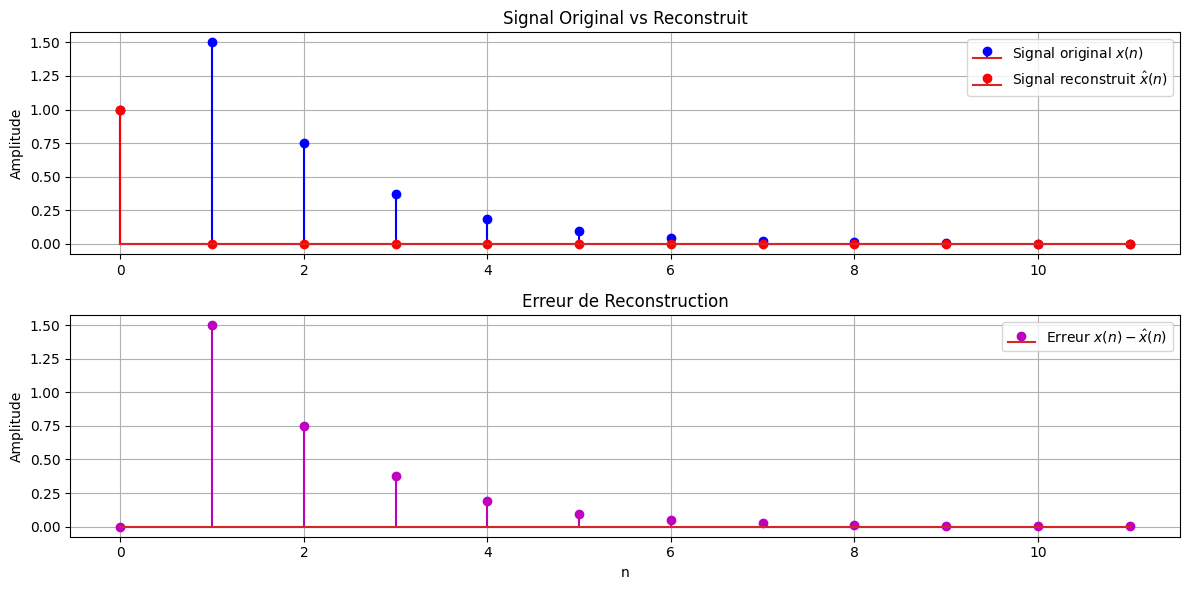

In [7]:
# --- 1. Paramètres du modèle ---
p = 0
q = 2

# --- 2. Construction de la matrice de convolution complète ---
X_full = get_conv_mtx(xn, p)
print("Matrice de convolution X_full :\n", X_full)

# --- 3. Extraction pour la méthode de Padé ---
# Xq : Matrice p x p extraite de X_full (lignes q+1 à q+p, colonnes 0 à p-1)
# Ici pour q=0, p=2 : lignes 0 à 1, colonnes 0 à 1
Xq = X_full[q:q+p, 0:p]

# xq_1 : Vecteur cible (échantillons de q+1 à q+p)
xq_1 = xn[q+1:q+p+1]

print("\nMatrice Xq :\n", Xq)
print("\nVecteur xq_1 :\n", xq_1)

# --- 4. Résolution du système pour les coefficients 'a' ---
# Système : Xq * a = -xq_1
# On utilise solve car Xq est carrée et non-singulière
ap_reduced = solve(Xq, -xq_1)

# Le vecteur complet des coefficients est [1, a1, a2]
ap = np.insert(ap_reduced, 0, 1.0)
print("\nCoefficients ap :", ap)

# --- 5. Calcul des coefficients 'b' (Numérateur) ---
# Pour un modèle AR pur (q=0), b0 = x(0) * a0 = 1.0 * 1.0
bq = np.array([xn[0]])
print("Coefficients bq :", bq)

# --- 6. Reconstruction et Erreur ---
# On filtre une impulsion avec notre modèle AR(2) pour voir s'il suit xn
x_hat = lfilter(bq, ap, np.eye(1, N)[0])
error_vec = xn - x_hat
els = np.sum(error_vec**2)

print(f"Erreur Els : {els:.4f}")

plt.figure(figsize=(12, 6))

# Subplot 1 : Comparaison des signaux
plt.subplot(2, 1, 1)
plt.stem(n, xn, linefmt='b-', markerfmt='bo', label='Signal original $x(n)$')
plt.stem(n, x_hat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
plt.title("Signal Original vs Reconstruit")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

# Subplot 2 : Erreur de reconstruction
plt.subplot(2, 1, 2)
plt.stem(n, error_vec, linefmt='m-', markerfmt='mo', label='Erreur $x(n) - \hat{x}(n)$')
plt.title("Erreur de Reconstruction")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Coefficients bq (MA) : [1.   1.5  0.75]
Erreur Els MA : 0.4330


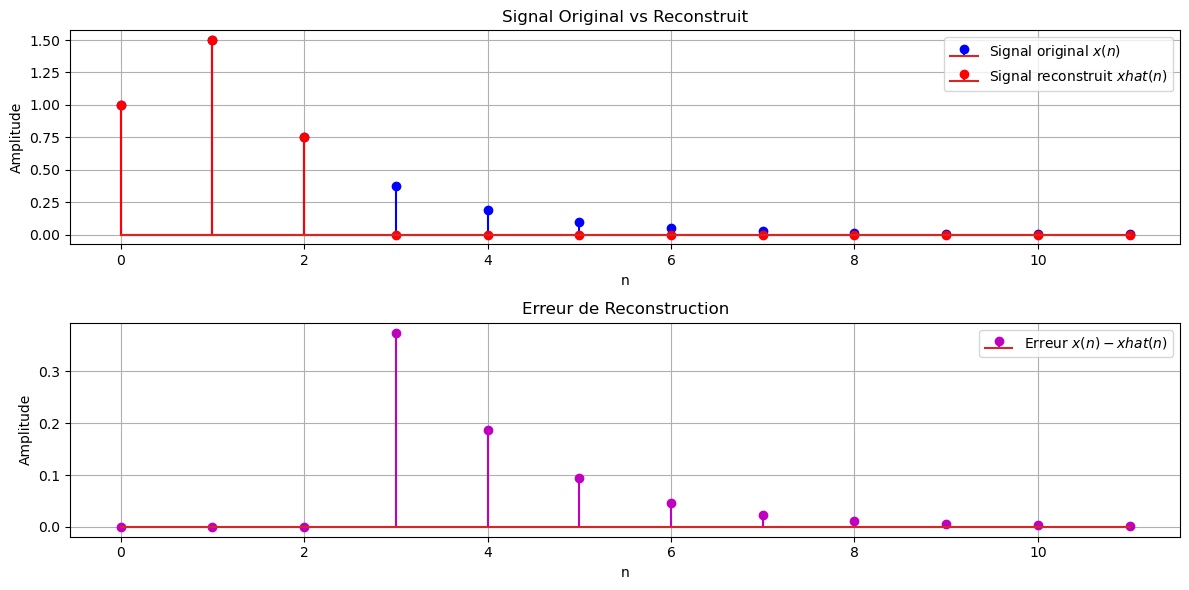

In [11]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

## 4. Test c) : Modèle ARMA(1,1) ($p=1, q=1$)
IIR à deux étapes :
1. Calcul de $a_p$ via les équations de Padé décalées.
2. Calcul de $b_q$ via la relation $b_q = X_{0:q} \cdot a_p$.

Matrice de convolution X_full :
 [[1.00000000e+00 0.00000000e+00]
 [1.50000000e+00 1.00000000e+00]
 [7.50000000e-01 1.50000000e+00]
 [3.75000000e-01 7.50000000e-01]
 [1.87500000e-01 3.75000000e-01]
 [9.37500000e-02 1.87500000e-01]
 [4.68750000e-02 9.37500000e-02]
 [2.34375000e-02 4.68750000e-02]
 [1.17187500e-02 2.34375000e-02]
 [5.85937500e-03 1.17187500e-02]
 [2.92968750e-03 5.85937500e-03]
 [1.46484375e-03 2.92968750e-03]]

Matrice Xq :
 [[1.5]]

Vecteur xq_1 :
 [0.75]

Coefficients ap : [ 1.  -0.5]
Coefficients bq : [1.]
Erreur Els : 1.3333


<>:47: SyntaxWarning: invalid escape sequence '\h'
<>:55: SyntaxWarning: invalid escape sequence '\h'
<>:47: SyntaxWarning: invalid escape sequence '\h'
<>:55: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_73134/1774536031.py:47: SyntaxWarning: invalid escape sequence '\h'
  plt.stem(n, x_hat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
/tmp/ipykernel_73134/1774536031.py:55: SyntaxWarning: invalid escape sequence '\h'
  plt.stem(n, error_vec, linefmt='m-', markerfmt='mo', label='Erreur $x(n) - \hat{x}(n)$')


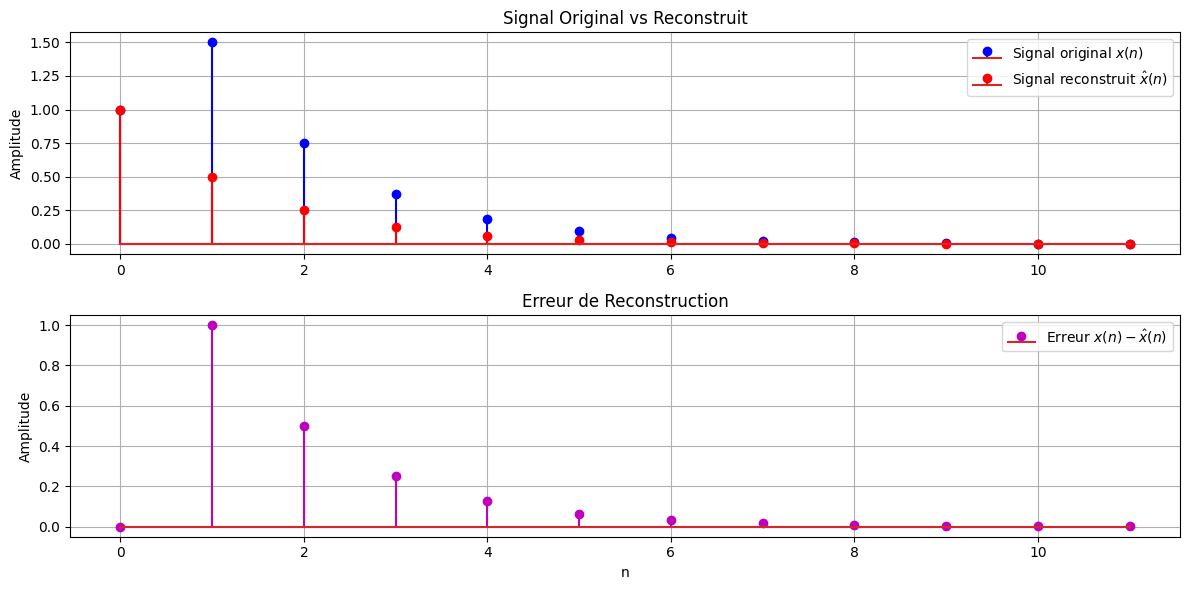

In [8]:
# --- 1. Paramètres du modèle ---
p = 1
q = 1

# --- 2. Construction de la matrice de convolution complète ---
X_full = get_conv_mtx(xn, p)
print("Matrice de convolution X_full :\n", X_full)

# --- 3. Extraction pour la méthode de Padé ---
# Xq : Matrice p x p extraite de X_full (lignes q+1 à q+p, colonnes 0 à p-1)
# Ici pour q=0, p=2 : lignes 0 à 1, colonnes 0 à 1
Xq = X_full[q:q+p, 0:p]

# xq_1 : Vecteur cible (échantillons de q+1 à q+p)
xq_1 = xn[q+1:q+p+1]

print("\nMatrice Xq :\n", Xq)
print("\nVecteur xq_1 :\n", xq_1)

# --- 4. Résolution du système pour les coefficients 'a' ---
# Système : Xq * a = -xq_1
# On utilise solve car Xq est carrée et non-singulière
ap_reduced = solve(Xq, -xq_1)

# Le vecteur complet des coefficients est [1, a1, a2]
ap = np.insert(ap_reduced, 0, 1.0)
print("\nCoefficients ap :", ap)

# --- 5. Calcul des coefficients 'b' (Numérateur) ---
# Pour un modèle AR pur (q=0), b0 = x(0) * a0 = 1.0 * 1.0
bq = np.array([xn[0]])
print("Coefficients bq :", bq)

# --- 6. Reconstruction et Erreur ---
# On filtre une impulsion avec notre modèle AR(2) pour voir s'il suit xn
x_hat = lfilter(bq, ap, np.eye(1, N)[0])
error_vec = xn - x_hat
els = np.sum(error_vec**2)

print(f"Erreur Els : {els:.4f}")

plt.figure(figsize=(12, 6))

# Subplot 1 : Comparaison des signaux
plt.subplot(2, 1, 1)
plt.stem(n, xn, linefmt='b-', markerfmt='bo', label='Signal original $x(n)$')
plt.stem(n, x_hat, linefmt='r-', markerfmt='ro', label='Signal reconstruit $\hat{x}(n)$')
plt.title("Signal Original vs Reconstruit")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

# Subplot 2 : Erreur de reconstruction
plt.subplot(2, 1, 2)
plt.stem(n, error_vec, linefmt='m-', markerfmt='mo', label='Erreur $x(n) - \hat{x}(n)$')
plt.title("Erreur de Reconstruction")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

ap ARMA(1,1) : [ 1.  -0.5]
bq ARMA(1,1) : [1. 1.]
Erreur Els ARMA(1,1) : 0.0


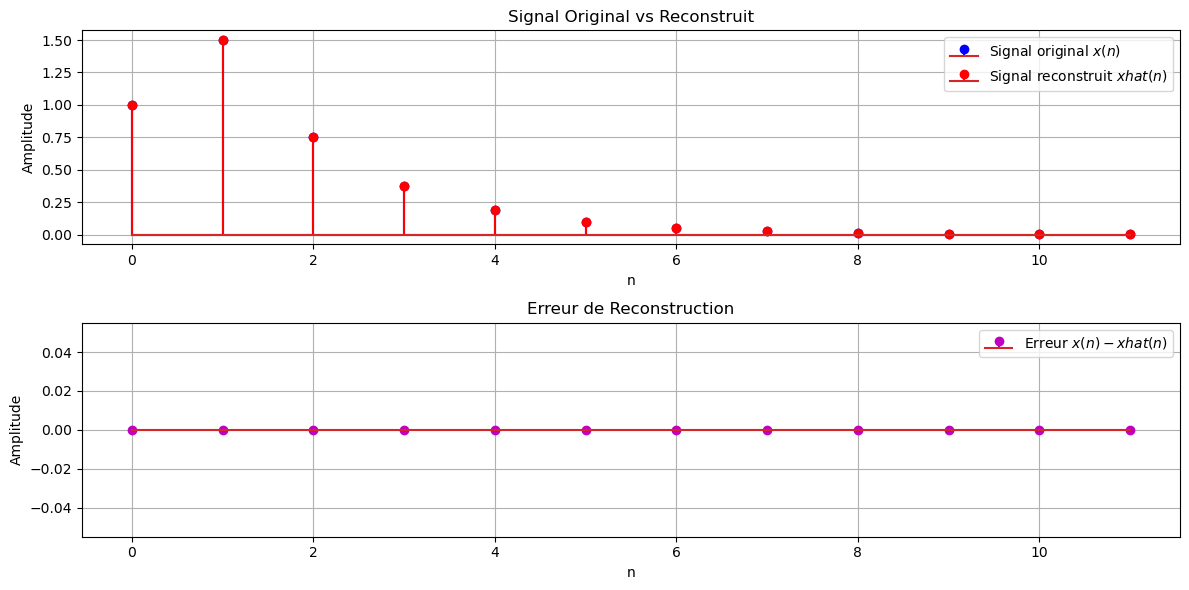

In [12]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

## 4.1.5. Fonction Générale pade(x, p, q)
Ecrivez une fonction qui automatise le calcul des coefficients de Padé pour n'importe quel ordre.

Prototype :
```Python 
def pade(x, p, q):
    N_sig = len(x)
    if p > 0:
        # 1. Résoudre pour ap
        
        # Vérification de singularité
        if np.linalg.det(Xq) == 0:
            raise ValueError("Xq est une matrice singulière !")
        
        
    else:
        ap = np.array([1.0])
    
    # 2. Résoudre pour bq
    
    
    # 3. Reconstruction
    
    
    return ap, bq, Els, xhat

```

In [11]:
def pade(x, p, q):
    """
    Computes Padé approximation coefficients for a given signal.
    
    Parameters:
    x : array_like - Input signal
    p : int        - Order of the denominator (poles)
    q : int        - Order of the numerator (zeros)
    
    Returns:
    ap   : array - Denominator coefficients [1, a1, ..., ap]
    bq   : array - Numerator coefficients [b0, b1, ..., bq]
    Els  : float - Squared error of reconstruction
    xhat : array - Reconstructed signal
    """
    N_sig = len(x)
    # 0. Generate the full convolution matrix (N_sig x p+1)
    X_full = get_conv_mtx(x, p)
    
    if p > 0:
        # 1. Solve for denominator coefficients ap
        # Extraction of Xq: rows from q+1 to q+p, columns from 1 to p
        Xq = X_full[q+1 : q+p+1, 1 : p+1]
        
        # Target vector: samples from q+1 to q+p (column 0 of X_full)
        x_target = x[q+1 : q+p+1]
        
        # Singularity check
        if np.linalg.det(Xq) == 0:
            raise ValueError("Xq est une matrice singulière ! Impossible de résoudre pour ap.")
        
        # Solve the system Xq * a_red = -x_target
        a_reduced = solve(Xq, -x_target)
        
        # Prepend a0 = 1.0 to get the full ap vector
        ap = np.insert(a_reduced, 0, 1.0)
    else:
        # If p=0, it's a pure MA model
        ap = np.array([1.0])
    
    # 2. Solve for numerator coefficients bq
    # The first q+1 equations relate b and a: b = X(0:q, 0:p) * a
    X_num = X_full[0 : q+1, 0 : p+1]
    bq = X_num @ ap
    
    # 3. Reconstruction
    # Create an impulse signal delta(n)
    impulse = np.zeros(N_sig)
    impulse[0] = 1.0
    
    # Filter the impulse with the identified ARMA(p, q) model
    xhat = lfilter(bq, ap, impulse)
    
    # Calculate the Least Squares Error (Els)
    Els = np.sum((x - xhat)**2)
    
    return ap, bq, Els, xhat

In [13]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

## 4.1.6  Exemple: Design de filtre

### 4.1.6.1 Définition du filtre idéal

L'objectif est de synthétiser un filtre à partir de contraintes fréquentielles. On souhaite un filtre passe-bas idéal avec une phase linéaire (retard pur) :
$$H(jf) = \begin{cases} e^{-j n_d 2\pi f} & \text{pour } |f| < F_p \\ 0 & \text{pour } F_p < |f| < 0.5 \end{cases}$$

Puisque la réponse en fréquence est une fonction rectangulaire, la réponse impulsionnelle désirée $h(n)$ est une fonction **sinc** décalée de $n_d$ échantillons pour assurer la causalité :
$$h(n) = 2 F_p \text{sinc}(2 F_p (n - n_d)) = \frac{\sin((n-n_d)\pi / 2)}{(n-n_d)\pi}$$


$N=100, F_p=0.25, n_d=5$.
Approximation avec un modèle ARMA(6,6).

<>:28: SyntaxWarning: invalid escape sequence '\h'
<>:28: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_73134/1641311254.py:28: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(n_axis, h_hat, 'r--', label='Identifiée $\hat{h}(n)$ (Padé)')


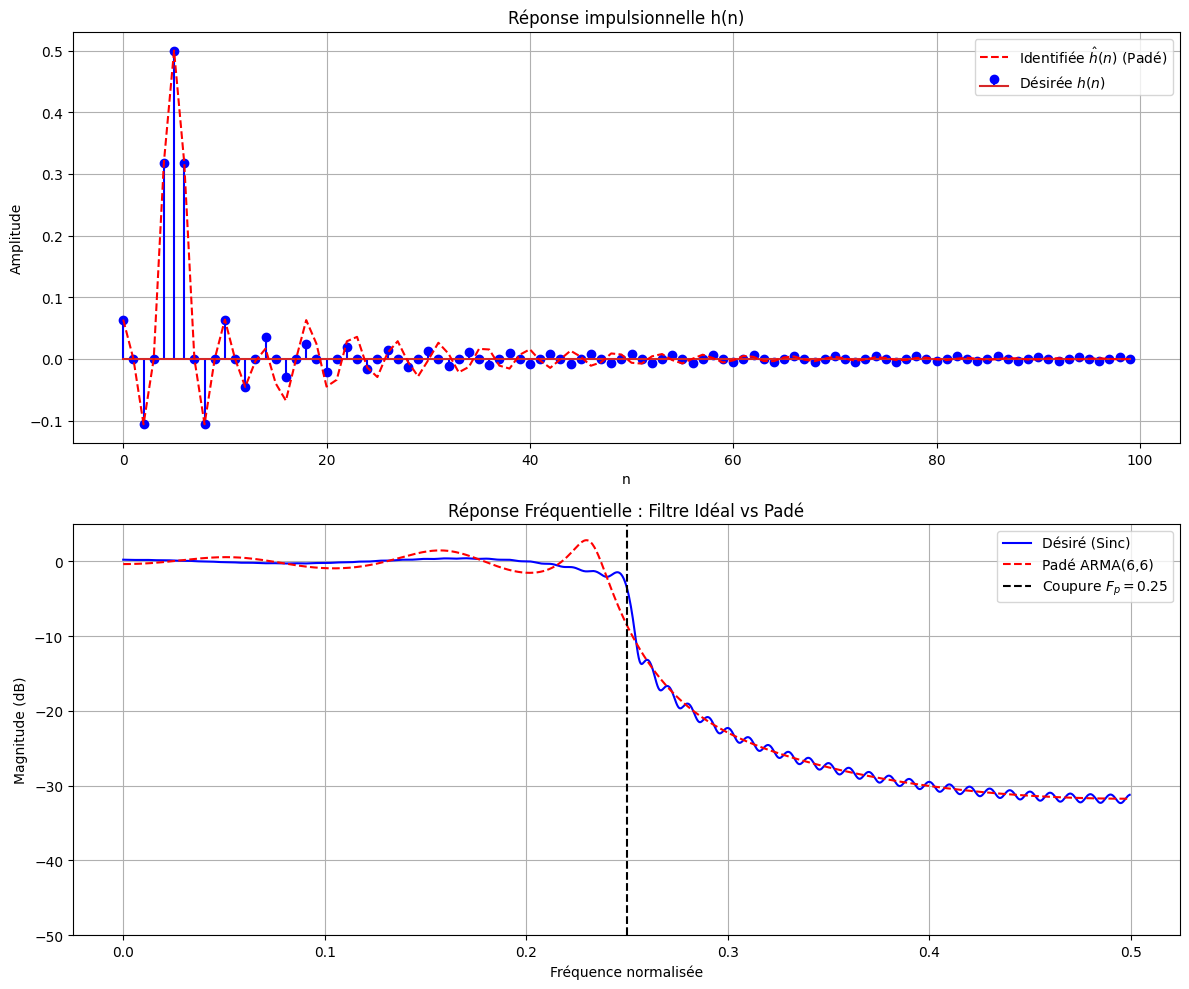

Erreur de reconstruction Els : 1.8634e-02


In [16]:
# --- 1. Paramètres du filtre ---
N = 100
Fp = 0.25
nd = 5
p, q = 6, 6  # Ordre ARMA(6,6)

# --- 2. Génération de h(n) désirée (Sinc décalée) ---
n_axis = np.arange(N)
hn = 2 * Fp * np.sinc(2 * Fp * (n_axis - nd))

# --- 3. Calcul du modèle Padé (via ta fonction) ---
ap, bq, Els, h_hat = pade(hn, p, q)

# --- 4. Calcul des réponses fréquentielles ---
# Réponse du filtre idéal (Sinc tronqué à N points)
W, H_ideal = freqz(hn, 1, worN=1024)
# Réponse du filtre synthétisé (Padé)
W, H_hat = freqz(bq, ap, worN=1024)

f_axis = W / (2 * np.pi) # Fréquence normalisée [0, 0.5]

# --- 5. Visualisation (conforme aux images 11cc3a et 11c404) ---
plt.figure(figsize=(12, 10))

# Sous-intrigue 1 : Domaine Temporel
plt.subplot(2, 1, 1)
plt.stem(n_axis, hn, linefmt='b-', markerfmt='bo', label='Désirée $h(n)$')
plt.plot(n_axis, h_hat, 'r--', label='Identifiée $\hat{h}(n)$ (Padé)')
plt.title("Réponse impulsionnelle h(n)") # Titre exact
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

# Sous-intrigue 2 : Domaine Fréquentiel (Comparaison)
plt.subplot(2, 1, 2)
# Tracé du filtre idéal (en bleu)
plt.plot(f_axis, 20 * np.log10(np.abs(H_ideal) + 1e-8), 'b-', label='Désiré (Sinc)')
# Tracé du modèle Padé (en rouge pointillé)
plt.plot(f_axis, 20 * np.log10(np.abs(H_hat) + 1e-8), 'r--', label='Padé ARMA(6,6)')

plt.axvline(Fp, color='k', linestyle='--', label=f'Coupure $F_p={Fp}$')
plt.title("Réponse Fréquentielle : Filtre Idéal vs Padé") # Titre exact
plt.xlabel("Fréquence normalisée")
plt.ylabel("Magnitude (dB)") # Label exact
plt.ylim([-50, 5])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Erreur de reconstruction Els : {Els:.4e}")

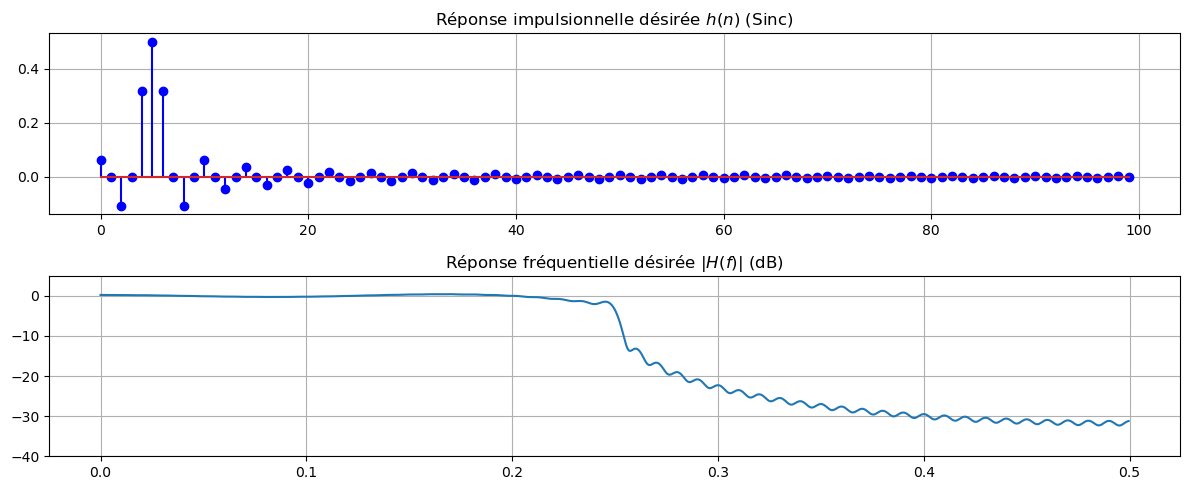

In [18]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

### 4.1.6.2 Synthèse  avec  fonction Padé  ordre p=6, q=6
Utiliser la  fonction Padé  poir  synthétiser le filtre $H(z)$ en  produisant une  réponse impulsionelle  comme  celle  du  filtre  voulu.

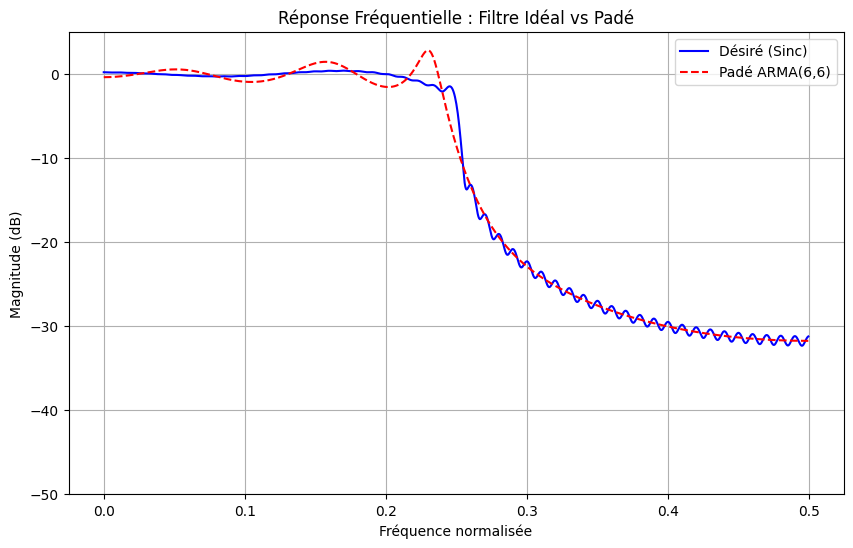

In [15]:
# --- 1. Calcul des réponses fréquentielles ---
# Réponse du filtre idéal (Sinc)
w_ideal, H_ideal = freqz(hn, 1, worN=1024)
# Réponse du filtre synthétisé (Padé ARMA 6,6)
w_pade, H_pade = freqz(bq, ap, worN=1024)

f_axis = w_ideal / (2 * np.pi)

# --- 2. Génération du Plot Unique ---
plt.figure(figsize=(10, 6))

# Tracé de la magnitude en dB pour le filtre idéal
plt.plot(f_axis, 20 * np.log10(np.abs(H_ideal) + 1e-8), 'b-', label='Désiré (Sinc)')

# Tracé de la magnitude en dB pour le modèle Padé
plt.plot(f_axis, 20 * np.log10(np.abs(H_pade) + 1e-8), 'r--', label='Padé ARMA(6,6)')

plt.title("Réponse Fréquentielle : Filtre Idéal vs Padé")
plt.xlabel("Fréquence normalisée")
plt.ylabel("Magnitude (dB)")
plt.ylim([-50, 5])
plt.legend()
plt.grid(True)

plt.show()

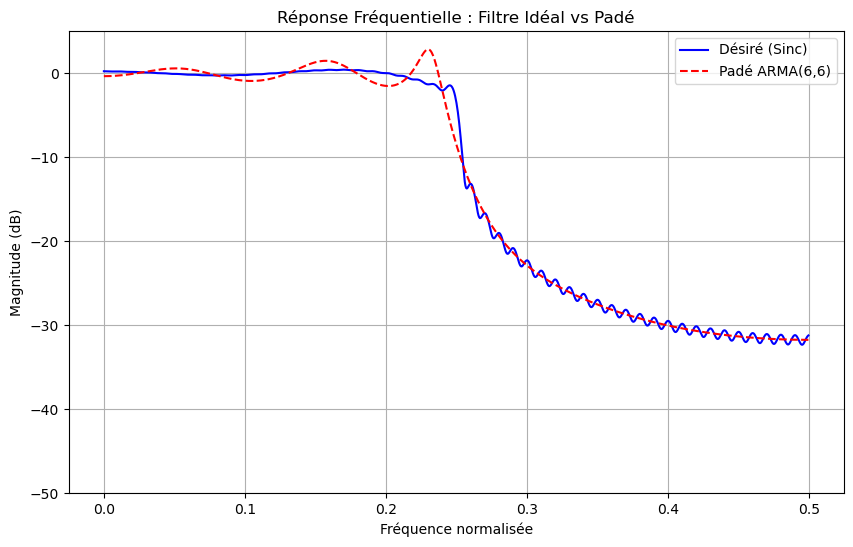

In [17]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]